In [1]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor, XGBClassifier
import shap
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyRegressor, LazyClassifier
from scipy.stats import randint, uniform, zscore, stats
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_percentage_error, accuracy_score, classification_report, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import TargetEncoder
from sklearn import linear_model
from sklearn.linear_model import Lasso, LogisticRegression, LinearRegression
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import OneHotEncoder, RobustScaler
import statsmodels.api as sm
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor
from sklearn.compose import ColumnTransformer
import joblib

In [2]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=416&path=medical_insurance_cost.csv')
pd.set_option('display.max_columns', None)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


In [3]:
df.shape

(1338, 7)

Valores unicos

In [4]:
uniques = df.nunique()
uniques

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

filas dup

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
filas_dup = df[df.duplicated(keep=False)]
filas_dup

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.56
581,19,male,30.59,0,no,northwest,1639.56


In [7]:
df.drop_duplicates(inplace=True)

Valores faltantes

In [8]:
faltantes = df.isna().mean()*100
print(faltantes)

age        0.00
sex        0.00
bmi        0.00
children   0.00
smoker     0.00
region     0.00
charges    0.00
dtype: float64


In [9]:
#identificar otros valores faltantes

cat_col = df.select_dtypes(include=['object']).columns

for col in cat_col: 
    print(df[col].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


<Axes: >

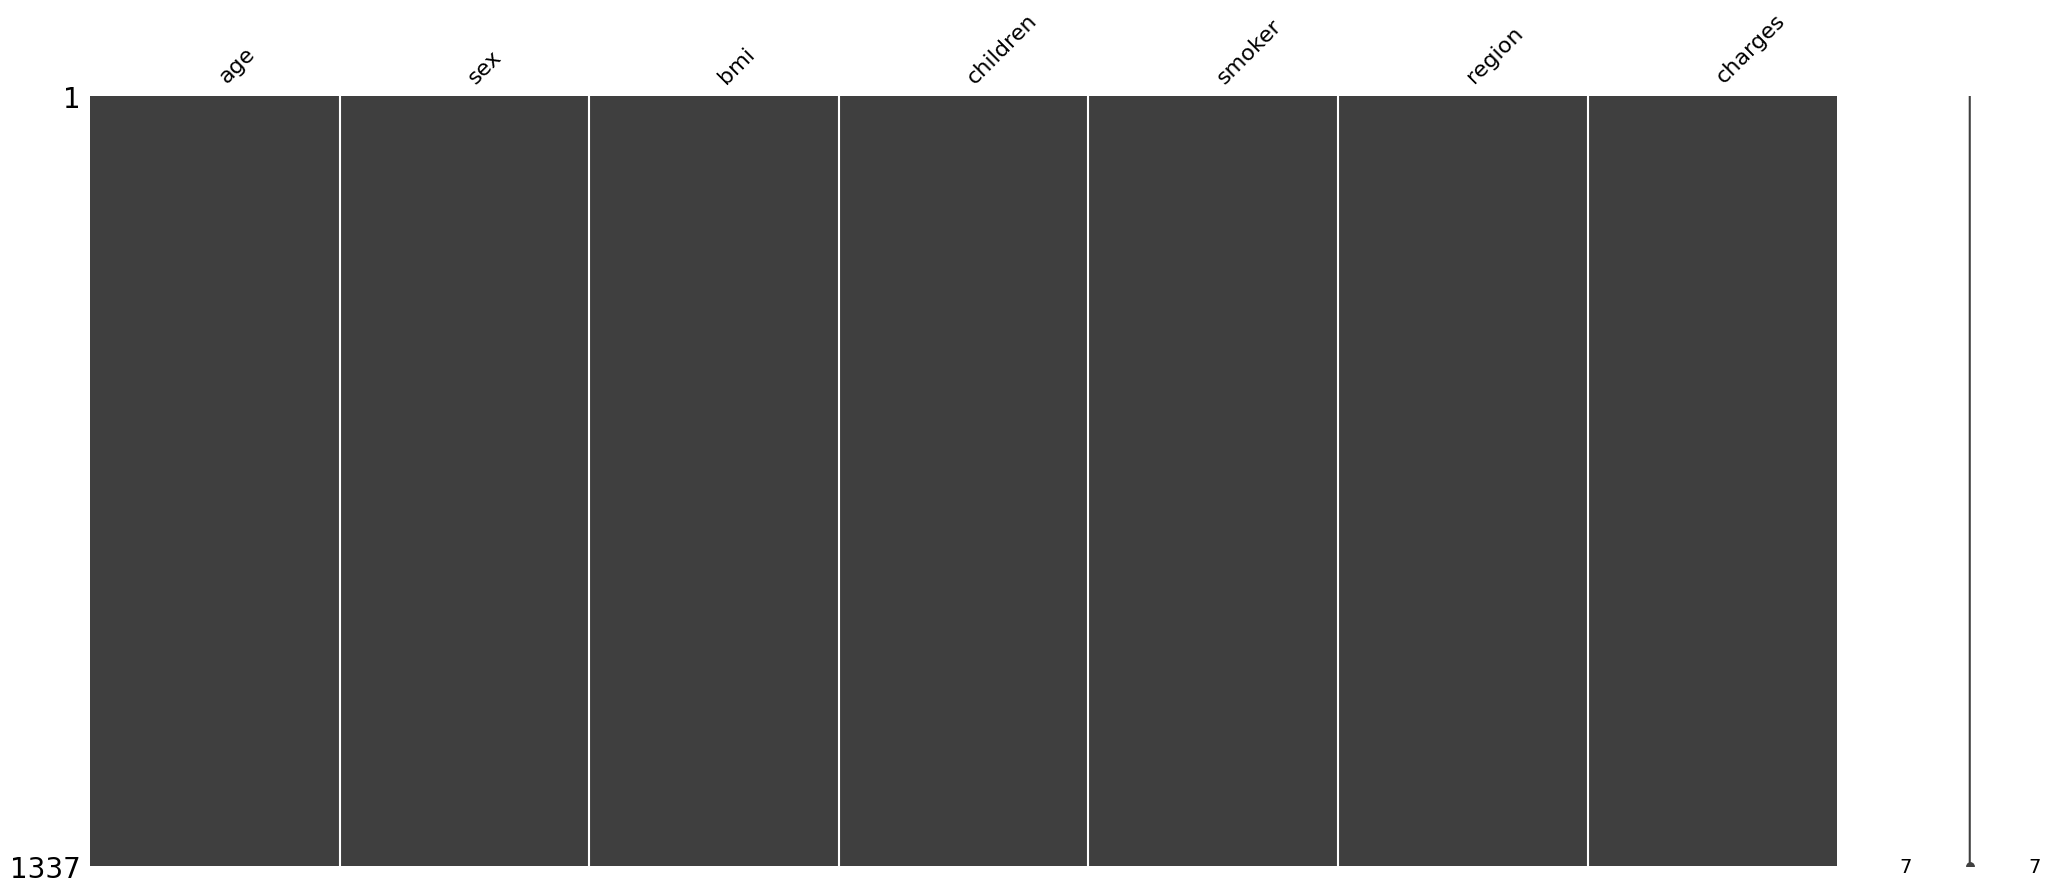

In [10]:
msno.matrix(df)

In [11]:
#df copy
df_raw = df.copy()

Cod. Variables categoricas (sex & smoker)

In [12]:
#mapear sex

df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.90,0,yes,southwest,16884.92
1,18,0,33.77,1,no,southeast,1725.55
2,28,0,33.00,3,no,southeast,4449.46
3,33,0,22.70,0,no,northwest,21984.47
4,32,0,28.88,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,0,30.97,3,no,northwest,10600.55
1334,18,1,31.92,0,no,northeast,2205.98
1335,18,1,36.85,0,no,southeast,1629.83
1336,21,1,25.80,0,no,southwest,2007.94


In [13]:
#mapear smoker
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.90,0,1,southwest,16884.92
1,18,0,33.77,1,0,southeast,1725.55
2,28,0,33.00,3,0,southeast,4449.46
3,33,0,22.70,0,0,northwest,21984.47
4,32,0,28.88,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,0,30.97,3,0,northwest,10600.55
1334,18,1,31.92,0,0,northeast,2205.98
1335,18,1,36.85,0,0,southeast,1629.83
1336,21,1,25.80,0,0,southwest,2007.94


Train Test Split

In [14]:
x = df.drop('charges',axis = 1)
y = df['charges']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Cod. Variables Cat (region)

In [16]:
#OneHotEncoder


encoder = OneHotEncoder(drop=None,sparse_output=False)

encoded_train = encoder.fit_transform(X_train[['region']])
encoded_test = encoder.transform(X_test[['region']])

new_cols = encoder.get_feature_names_out(['region'])

X_train[new_cols] = encoded_train
X_test[new_cols] = encoded_test

X_train.drop('region',axis=1,inplace=True)
X_test.drop('region',axis=1,inplace=True)


In [17]:
X_train.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
1114,23,0,24.51,0,0,1.00,0.00,0.00,0.00
968,21,0,25.75,2,0,1.00,0.00,0.00,0.00
599,52,1,37.52,2,0,0.00,1.00,0.00,0.00
170,63,0,41.47,0,0,0.00,0.00,1.00,0.00
275,47,1,26.60,2,0,1.00,0.00,0.00,0.00


Outliers

In [18]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1069.00,39.20,14.00,18.00,27.00,39.00,51.00,64.00
sex,1069.00,0.49,0.50,0.00,0.00,0.00,1.00,1.00
bmi,1069.00,30.54,6.05,15.96,26.18,30.20,34.43,53.13
children,1069.00,1.08,1.19,0.00,0.00,1.00,2.00,5.00
smoker,1069.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00
region_northeast,1069.00,0.24,0.43,0.00,0.00,0.00,0.00,1.00
region_northwest,1069.00,0.25,0.43,0.00,0.00,0.00,0.00,1.00
region_southeast,1069.00,0.27,0.44,0.00,0.00,0.00,1.00,1.00
region_southwest,1069.00,0.25,0.43,0.00,0.00,0.00,0.00,1.00


In [20]:
# Lista de columnas que quiero analizar
columnas = ['age', 'bmi', 'children']

# Para guardar los resultados
resultados = []

# Analizar cada columna una por una
for columna in columnas:
    
    # Obtener los datos de la columna
    datos = df[columna]
    
    # Calcular Q1 (25%), Q3 (75%) y IQR
    Q1 = datos.quantile(0.25)  # 25% de los datos
    Q3 = datos.quantile(0.75)  # 75% de los datos
    IQR = Q3 - Q1              # Diferencia entre Q3 y Q1
    
    # Calcular límites
    limite_bajo = Q1 - 1.5 * IQR
    limite_alto = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_bajos = (datos < limite_bajo).sum()
    outliers_altos = (datos > limite_alto).sum()
    total_outliers = outliers_bajos + outliers_altos
    
    # Calcular porcentaje
    porcentaje = (total_outliers / len(datos)) * 100
    
    # Guardar en la lista
    resultados.append({
        'Columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Bajo': limite_bajo,
        'Limite_Alto': limite_alto,
        'Total_Outliers': total_outliers,
        'Porcentaje': round(porcentaje, 2)
    })

# Convertir a DataFrame para verlo bonito
df_outliers = pd.DataFrame(resultados)

# Mostrar resultados
print("="*80)
print("ANÁLISIS DE OUTLIERS")
print("="*80)
print(df_outliers)
print("="*80)

# Explicar qué significa
print("\n💡 INTERPRETACIÓN:")
for i in range(len(df_outliers)):
    col = df_outliers.loc[i, 'Columna']
    limite_bajo = df_outliers.loc[i, 'Limite_Bajo']
    limite_alto = df_outliers.loc[i, 'Limite_Alto']
    total = df_outliers.loc[i, 'Total_Outliers']
    pct = df_outliers.loc[i, 'Porcentaje']
    
    print(f"\n{col}:")
    print(f"  - Valores normales: entre {limite_bajo:.1f} y {limite_alto:.1f}")
    print(f"  - Outliers encontrados: {total} ({pct}%)")
    
    if pct < 5:
        print(f"  ✅ Pocos outliers, está bien")
    elif pct < 10:
        print(f"  ⚠️ Algunos outliers")
    else:
        print(f"  ❌ Muchos outliers")

ANÁLISIS DE OUTLIERS
    Columna    Q1    Q3   IQR  Limite_Bajo  Limite_Alto  Total_Outliers  \
0       age 27.00 51.00 24.00        -9.00        87.00               0   
1       bmi 26.29 34.70  8.41        13.67        47.32               9   
2  children  0.00  2.00  2.00        -3.00         5.00               0   

   Porcentaje  
0        0.00  
1        0.67  
2        0.00  

💡 INTERPRETACIÓN:

age:
  - Valores normales: entre -9.0 y 87.0
  - Outliers encontrados: 0 (0.0%)
  ✅ Pocos outliers, está bien

bmi:
  - Valores normales: entre 13.7 y 47.3
  - Outliers encontrados: 9 (0.67%)
  ✅ Pocos outliers, está bien

children:
  - Valores normales: entre -3.0 y 5.0
  - Outliers encontrados: 0 (0.0%)
  ✅ Pocos outliers, está bien


In [21]:
iso = IsolationForest(random_state=123)
df_train_outliers = X_train.copy()
df_train_outliers['outlier_flag'] = iso.fit_predict(X_train)

In [22]:
df_train_outliers['outlier_flag'].value_counts()

outlier_flag
-1    622
 1    447
Name: count, dtype: int64

Selecc. Caract.

In [23]:
#METODO 1:
#RandomForest

#1: entrenamiento RF

model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1).fit(X_train,y_train)

In [24]:
#Importancia caract.
importances = model.feature_importances_/model.feature_importances_.sum()*100

#Convertir a dataframe
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

#importancia acumulada
df_rf_imp['rf_importance_accum'] = df_rf_imp['rf_importance'].cumsum()

df_rf_imp

,feature,rf_importance,rf_importance_accum
4,smoker,60.08,60.08
2,bmi,21.31,81.39
0,age,13.55,94.95
3,children,2.29,97.23
1,sex,0.73,97.97
6,region_northwest,0.60,98.56
7,region_southeast,0.56,99.12
5,region_northeast,0.50,99.63
8,region_southwest,0.37,100.00


In [25]:
#METODO 2
#XGB

#crear conjunto de val
X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.2,random_state=42)

#ajustar modelo

model_xgb = XGBRegressor(objective='reg:squarederror',random_state=42).fit(X_train1,y_train1)

In [26]:
# Realizamos 10 permutaciones por cada característica
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_mean_absolute_percentage_error')

In [27]:
df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
4,smoker,60.37
0,age,56.43
3,children,9.74
2,bmi,7.62
6,region_northwest,0.21
1,sex,-0.13
5,region_northeast,-0.66
8,region_southwest,-0.72
7,region_southeast,-2.46


In [ ]:
#METODO 3: SHAP

In [28]:
X_val_shap = X_val[X_train1.columns].copy()
model_lgbm = lgb.LGBMRegressor(random_state=42, n_jobs=-1)
model_lgbm.fit(X_train1, y_train1)

explainer = shap.Explainer(model_lgbm)   # usa el mismo X_val
shap_vals = explainer(X_val_shap,check_additivity=False).values

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 855, number of used features: 9
[LightGBM] [Info] Start training from score 13131.545132
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [29]:
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
4,smoker,49.12
0,age,22.80
2,bmi,15.08
3,children,7.17
8,region_southwest,1.52
1,sex,1.45
5,region_northeast,1.24
7,region_southeast,1.12
6,region_northwest,0.51


union 3 metodos

In [30]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_accum,perm_imp,shap_imp
8,smoker,60.08,60.08,60.37,49.12
1,bmi,21.31,81.39,7.62,15.08
0,age,13.55,94.95,56.43,22.80
2,children,2.29,97.23,9.74,7.17
7,sex,0.73,97.97,-0.13,1.45
4,region_northwest,0.60,98.56,0.21,0.51
5,region_southeast,0.56,99.12,-2.46,1.12
3,region_northeast,0.50,99.63,-0.66,1.24
6,region_southwest,0.37,100.00,-0.72,1.52


In [31]:
df_filt = df_importances[(df_importances['rf_importance']>=1)&(df_importances['perm_imp']>=1)&(df_importances['shap_imp']>=1)]
df_filt

,feature,rf_importance,rf_importance_accum,perm_imp,shap_imp
8,smoker,60.08,60.08,60.37,49.12
1,bmi,21.31,81.39,7.62,15.08
0,age,13.55,94.95,56.43,22.80
2,children,2.29,97.23,9.74,7.17


In [32]:
features = df_filt['feature']
features

8      smoker
1         bmi
0         age
2    children
Name: feature, dtype: object

In [33]:
X_vif = add_constant(X_train[features])

vif = pd.DataFrame([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],index=X_vif.columns)
vif = vif.drop("const")
vif

,0
smoker,1.00
bmi,1.02
age,1.02
children,1.00


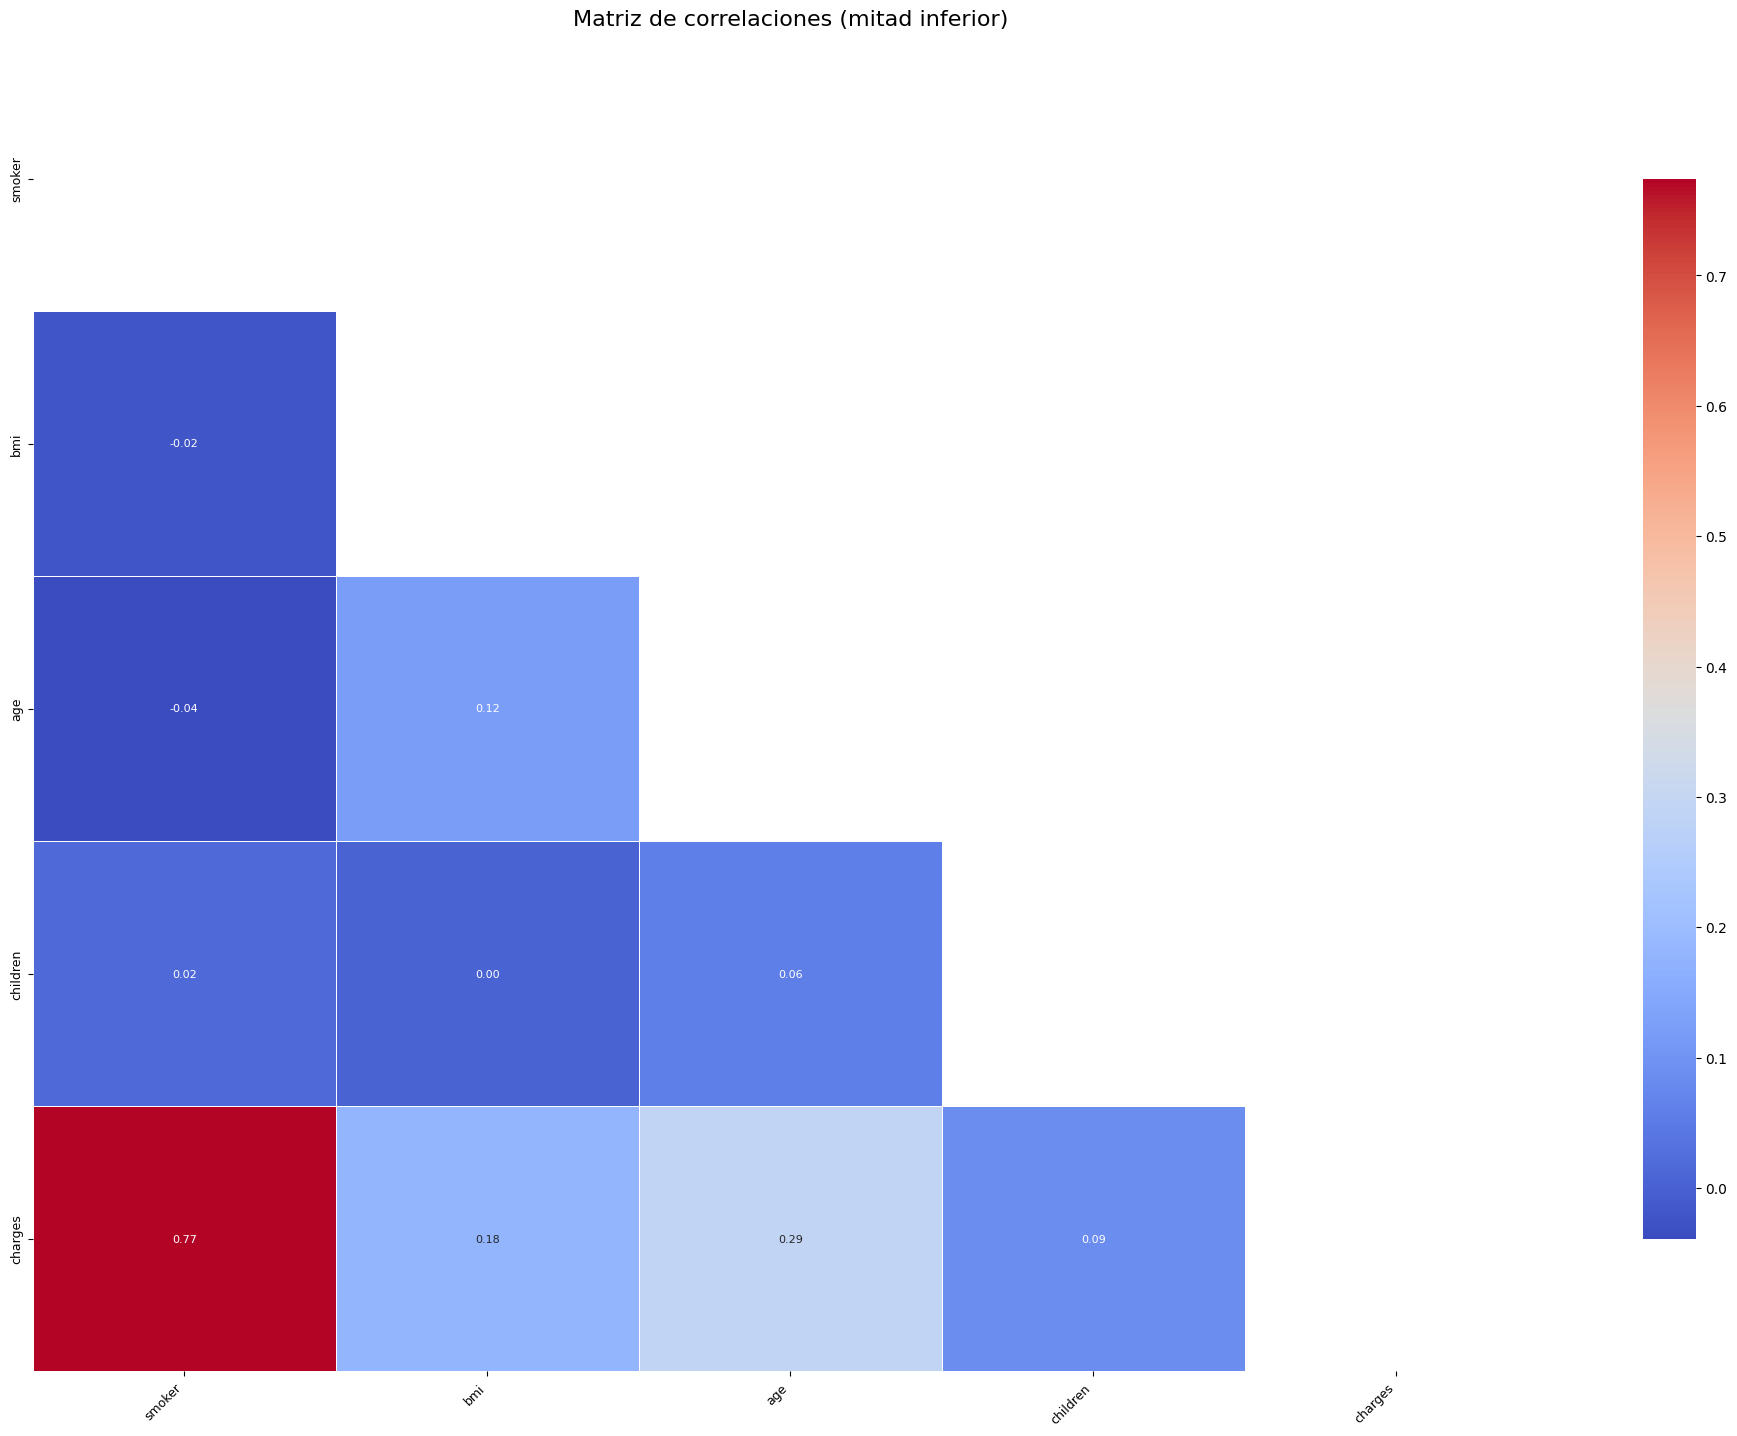

In [34]:
X_copy = X_train[features].copy()
X_copy['charges'] = y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

Cross Validation

In [35]:
#V1
cv_results1 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features], y_train, cv=3, scoring='neg_mean_absolute_error')

In [36]:
cv_results1.mean()*-1

np.float64(2720.1937785728755)

In [37]:
#V2
cv_results2 = cross_val_score(RandomForestRegressor(random_state=42,n_jobs=-1), X_train[features].drop(['smoker'],axis=1),y_train, cv=3, scoring='neg_mean_absolute_error')

In [38]:
cv_results2.mean()*-1

np.float64(8830.577910775946)

Modelado

In [ ]:

X_train_sel = X_train[features]
X_test_sel = X_test[features]



In [40]:
X_train_sel.describe().T

,count,mean,std,min,25%,50%,75%,max
smoker,1069.00,0.20,0.40,0.00,0.00,0.00,0.00,1.00
bmi,1069.00,30.54,6.05,15.96,26.18,30.20,34.43,53.13
age,1069.00,39.20,14.00,18.00,27.00,39.00,51.00,64.00
children,1069.00,1.08,1.19,0.00,0.00,1.00,2.00,5.00


In [41]:
y_train.skew()

np.float64(1.5098846374989072)

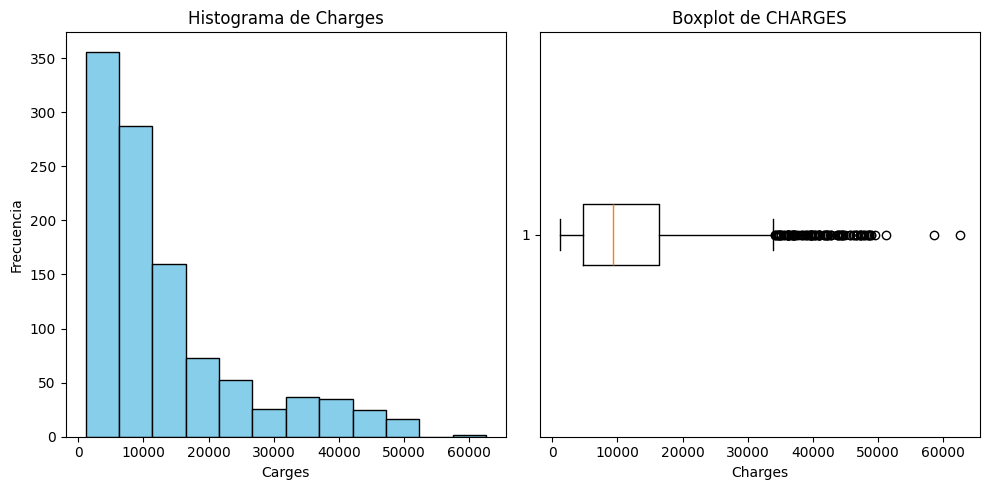

In [42]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Crear un histograma en el primer subplot
ax[0].hist(y_train, bins='sturges', color='skyblue', edgecolor='black')
ax[0].set_title('Histograma de Charges')
ax[0].set_xlabel('Carges')
ax[0].set_ylabel('Frecuencia')

# Crear un boxplot en el segundo subplot
ax[1].boxplot(y_train, vert=False)
ax[1].set_title('Boxplot de CHARGES')
ax[1].set_xlabel('Charges')

# Mostrar la figura
plt.tight_layout()
plt.show()

In [43]:
# Transformamos la variable respuesta en escala logarítmica
y_train = np.log(y_train)
y_test = np.log(y_test)

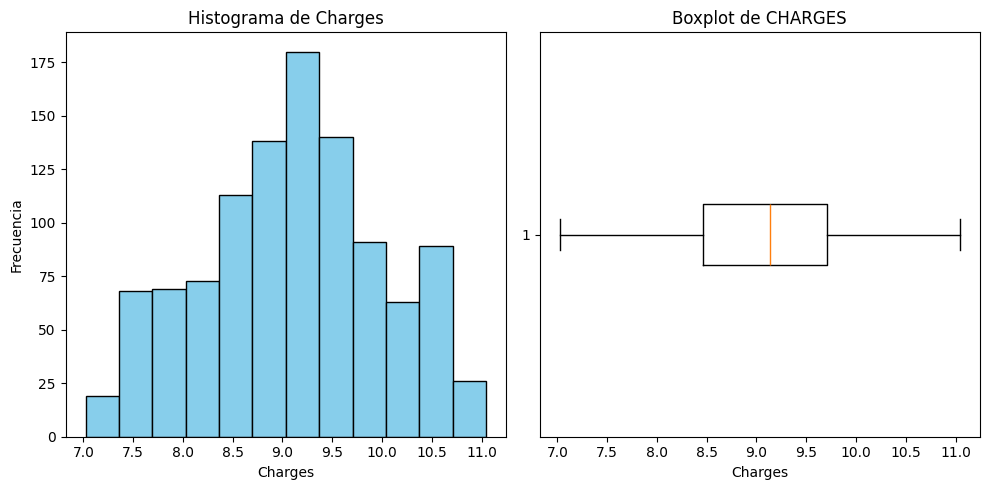

In [44]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Crear un histograma en el primer subplot
ax[0].hist(y_train, bins='sturges', color='skyblue', edgecolor='black')
ax[0].set_title('Histograma de Charges')
ax[0].set_xlabel('Charges')
ax[0].set_ylabel('Frecuencia')

# Crear un boxplot en el segundo subplot
ax[1].boxplot(y_train, vert=False)
ax[1].set_title('Boxplot de CHARGES')
ax[1].set_xlabel('Charges')

# Mostrar la figura
plt.tight_layout()
plt.show()

In [ ]:
# scaler = StandardScaler()

# X_train_sc = scaler.fit_transform(X_train_final)
# X_test_sc = scaler.transform(X_test_final)

#aqui tambien pude haber usado robust scaler 

In [45]:
#RobustScaler

scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_sel)
X_test_sc = scaler.transform(X_test_sel)

Entrenamiento del modelo

In [46]:
modelv1 = LinearRegression()
modelv1.fit(X_train_sc,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
#pred

y_pred1 = modelv1.predict(X_test_sc)
y_pred1

array([ 8.92725331,  8.67637157,  9.44469775, 10.26363491,  8.68163801,
        9.28819055,  9.91417769,  8.02240772,  8.96270196,  9.29379083,
        9.32263758, 10.60658171, 10.08946995,  9.5681552 ,  8.81536176,
        9.05689204,  8.1473205 , 10.24318018,  8.35310453,  8.41876843,
        8.04719969, 10.16628848,  9.34359545, 10.27189941, 10.04393199,
        8.28841406, 10.60403361, 10.93865038,  9.11594693,  9.43401007,
        8.4028972 ,  9.21757572,  7.97514111,  9.42300931, 10.88989239,
        9.22104033,  8.46642936,  8.54992318, 10.57157368,  8.98402672,
        8.18856882, 10.42043973, 10.69122261,  9.20067876,  8.99734296,
        8.24381037,  8.05677406,  8.90118859,  8.34537792,  8.89057279,
        8.5212116 ,  8.80087304, 10.37631322,  8.05073617,  9.03031614,
        9.04399682,  9.151811  ,  8.20606324, 10.14641046,  8.94026129,
        9.53086997,  8.6736069 ,  9.32891239,  7.9050804 ,  9.56802768,
        9.2776151 ,  8.80670595, 10.30330544,  9.4809229 ,  9.62

In [48]:
y_pred_real = np.exp(y_pred1)
y_test_real = np.exp(y_test)

Evaluation Metrics

In [49]:
#MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test_real,y_pred_real)
print(f'mae:{mae}')

#RMSE
mse = mean_squared_error(y_test_real,y_pred_real)

rmse = np.sqrt(mse)
print(f'rmse: {rmse}')

#R2
r_squared = r2_score(y_test_real,y_pred_real)
print(f'r2: {r_squared}')


mae:3871.0450977335076
rmse: 7183.698845588628
r2: 0.719162851177694


1. El modelo explica el 71.9% de la variabilidad del costo del seguro 
2. El modelo representa un error medio absoluto de aprox $3871 

Hyper parameters tunning

NOTA: Aunque en este ejercicio se hizo búsqueda de hiper parámetros(extensiva), el modelo utilizado LinearRegression, no tiene parámetros que modfiquen la estructura del modelo, por lo cual, para esto, tendríamos que utilizar otro modelo. 

Busq. Extensiva

In [ ]:
# model = LinearRegression()

# param_grid = {
#     'fit_intercept': [True, False],
#     'copy_X': [True, False],
#     'positive': [True, False]
# }

# #randomized searchcv

# random_search = RandomizedSearchCV(estimator=model,param_distributions=param_grid,n_iter=5,scoring='neg_mean_absolute_error',cv=5,verbose=4,n_jobs=-1,random_state=123)

# random_search.fit(X_train_sc,y_train)


# print("Mejores hiperparámetros:")
# print(random_search.best_params_)

# best_model = random_search.best_estimator_


Exportación de modelo final

In [50]:
joblib.dump(modelv1,'linear_model.pkl')

['linear_model.pkl']

pregunta: debo cargar tambien el scaler y encoders??